# Hands-On Linear Regression with Scikit-Learn in Python (Beginner Friendly)

https://www.youtube.com/watch?v=ukZn2RJb7TU

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression

In [2]:
np.random.seed(42)

num_samples = 500

years_of_experience = np.random.randint(2, 21, size=num_samples)
slope = (200_000 - 60_000) / 18
intercept = 60_000

salaries = slope * years_of_experience + intercept + np.random.normal(0, 10_000, size=num_samples)

data = {'Years of Experience': years_of_experience, 'Salary': salaries}
df = pd.DataFrame(data)
df

,Years of Experience,Salary
0,8,115037.780010
1,16,182309.972927
2,12,156442.408989
3,9,144753.562169
4,8,130798.818454
...,...,...
495,18,203824.097462
496,8,123886.744304
497,14,173813.401529
498,5,101780.575328


In [3]:
df.describe()

,Years of Experience,Salary
count,500.000000,500.000000
mean,10.616000,142570.011096
std,5.662922,44935.263058
min,2.000000,54881.134555
25%,5.750000,104426.300731
50%,10.000000,139865.032545
75%,16.000000,182341.125962
max,20.000000,241879.376204


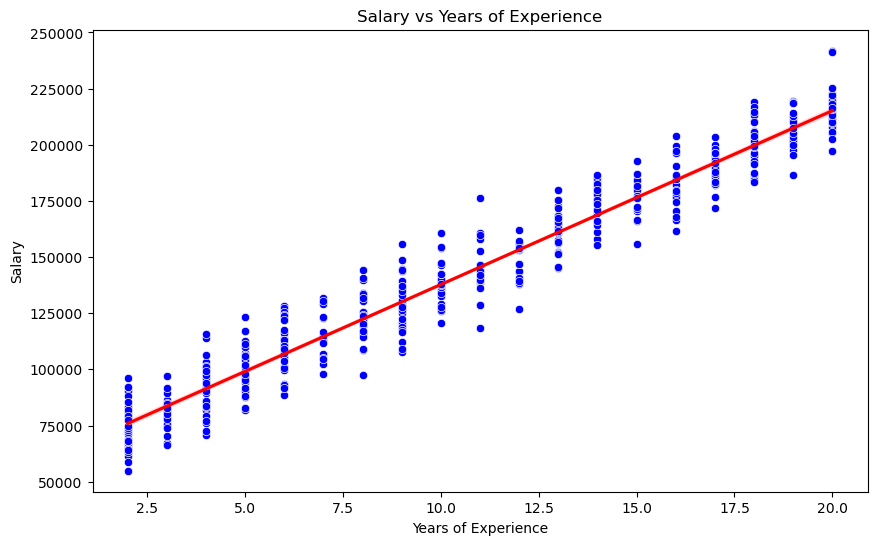

In [6]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Years of Experience', y='Salary', data=df, color='blue')
sns.regplot(x='Years of Experience', y='Salary', data=df, scatter=False, color='red')

plt.xlabel('Years of Experience')
plt.ylabel('Salary')
plt.title('Salary vs Years of Experience')
plt.show()

In [7]:
from sklearn.model_selection import train_test_split

X = df[['Years of Experience']]
y = df['Salary']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [8]:
lr = LinearRegression()
lr.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[7696.61]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['Years of Experience']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,6.096e+04
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,1


In [11]:
lr.score(X_train, y_train)

0.9488372177019488

In [12]:
lr.score(X_test, y_test)


0.9573704756930143

In [13]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
y_pred = lr.predict(X_test)

In [17]:
mean_absolute_error(y_test, y_pred)

7905.114728709235

In [18]:
mean_squared_error(y_test, y_pred)

93933277.37947097

In [19]:
r2_score(y_test, y_pred)

0.9573704756930143

In [21]:
lr.coef_

array([7696.61292305])

In [22]:
lr.intercept_

np.float64(60961.340880280535)

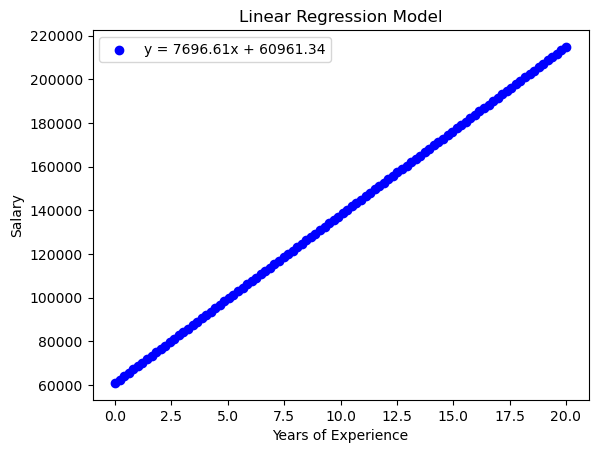

In [24]:
coefficients = lr.coef_
intercept = lr.intercept_

X = np.linspace(0, 20, 100)
y = coefficients * X + intercept

plt.scatter(X, y, label=f'y = {coefficients[0]:.2f}x + {intercept:.2f}', color='blue')
plt.xlabel('Years of Experience')
plt.ylabel('Salary')
plt.title('Linear Regression Model')
plt.legend()
plt.show()